# View All Output Photos

This notebook finds and displays all image files in this folder and all subfolders.

---

In [14]:
from pathlib import Path
from PIL import Image, ImageOps, ImageDraw
import math

root = Path.cwd()
exclude_name_parts = (
    "all_outputs_combined",
    "all-output-photos",
    "view-all-output",
)

image_paths = sorted(
    p for p in root.rglob("*.png")
    if not any(part in p.stem.lower() for part in exclude_name_parts)
)

if not image_paths:
    raise ValueError("No PNG files found.")

cols = 5                     
thumb_width = 900            
padding = 30
label_height = 50
bg_color = "white"
text_color = "black"

tiles = []
for p in image_paths:
    img = Image.open(p).convert("RGB")
    new_h = int(img.height * (thumb_width / img.width))
    img = img.resize((thumb_width, new_h), Image.Resampling.LANCZOS)
    tiles.append((p.stem, img))

rows = math.ceil(len(tiles) / cols)
max_h_per_row = [0] * rows

for i, (_, im) in enumerate(tiles):
    r = i // cols
    max_h_per_row[r] = max(max_h_per_row[r], im.height + label_height)

sheet_w = cols * thumb_width + (cols + 1) * padding
sheet_h = sum(max_h_per_row) + (rows + 1) * padding

sheet = Image.new("RGB", (sheet_w, sheet_h), bg_color)
draw = ImageDraw.Draw(sheet)

y = padding
for r in range(rows):
    x = padding
    for c in range(cols):
        idx = r * cols + c
        if idx >= len(tiles):
            break
        name, im = tiles[idx]
        sheet.paste(im, (x, y))
        draw.text((x, y + im.height + 10), name, fill=text_color)
        x += thumb_width + padding
    y += max_h_per_row[r] + padding

out_path = root / "All-Output-Photos.png"
sheet.save(out_path, quality=95)

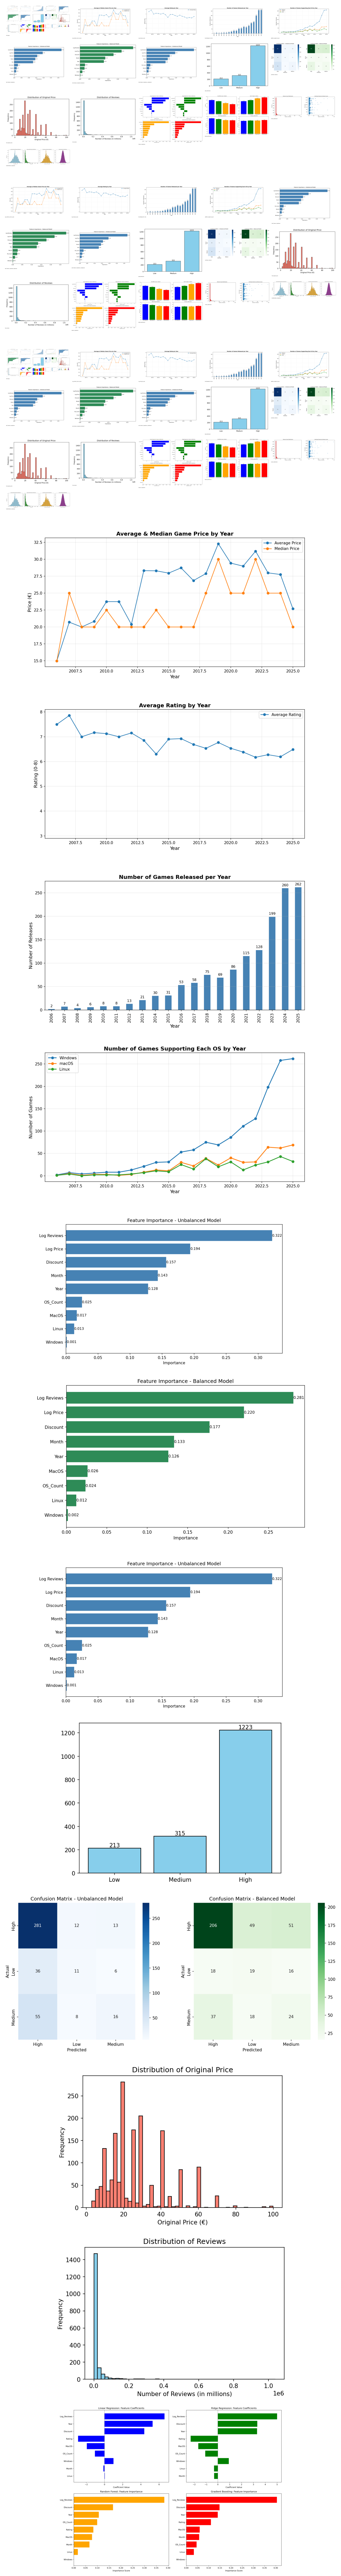

In [15]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

root = Path.cwd()
image_exts = {'.png', '.jpg', '.jpeg', '.gif', '.webp', '.bmp', '.tif', '.tiff'}

image_files = sorted(
    p for p in root.rglob('*')
    if p.is_file() and p.suffix.lower() in image_exts
)

if not image_files:
    print('No images found. Add photos in this folder/subfolders, then rerun.')
else:
    max_images = 15
    display_files = image_files[:max_images]

    rows = max_images
    cols = 1
    fig, axes = plt.subplots(rows, cols, figsize=(12, 6 * rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax in axes:
        ax.axis('off')

    for idx, img_path in enumerate(display_files):
        ax = axes[idx]
        try:
            with Image.open(img_path) as img:
                ax.imshow(img.convert('RGB'))
        except Exception as e:
            ax.text(0.5, 0.5, f'Cannot open\n{img_path.name}\n{e}', ha='center', va='center')
        ax.axis('off')

    plt.tight_layout()
    plt.show()